In [41]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiPoint, mapping

In [3]:
# for the langoid CSV file 
df = pd.read_csv("glottolog_languoid.csv/languoid.csv") 
df.head() 

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [4]:
df.columns

Index(['id', 'family_id', 'parent_id', 'name', 'bookkeeping', 'level',
       'latitude', 'longitude', 'iso639P3code', 'description',
       'markup_description', 'child_family_count', 'child_language_count',
       'child_dialect_count', 'country_ids'],
      dtype='str')

In [9]:
# above, it seems that the name, level, latitude, longitude, and iso639P3code are all relevant

In [5]:
tamil = df[df["name"] == "Tamil"]
tamil

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
22917,tami1289,drav1251,tami1300,Tamil,False,language,10.520219,78.825989,tam,NaN,NaN,0,0,18,IN LK


In [6]:
malayalam = df[df["name"] == "Malayalam"]
malayalam

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
13316,mala1464,drav1251,mala1541,Malayalam,False,language,9.59208,76.7651,mal,NaN,NaN,0,0,13,IN


In [1]:
## above it appears that we got our coordinates
## now we gotta turn the latitude and longitude to a geographical object and place it on a map surface 

In [7]:
tamil_longitude_val = tamil["longitude"].iloc[0]
tamil_latitude_val = tamil["latitude"].iloc[0]
# created a geometric object in coordinate space 
tamil_point = Point(tamil_longitude_val, tamil_latitude_val)

In [8]:
type(tamil_point)

shapely.geometry.point.Point

In [9]:
## need to put the point into a geodataframe 
tamil_gdf = gpd.GeoDataFrame(
    {
        "name": ["Tamil"],
        "iso": ["tam"],
        "geometry": [tamil_point]
    },
    crs="EPSG:4326"
)

In [10]:
tamil_gdf

,name,iso,geometry
0,Tamil,tam,POINT (78.82599 10.52022)


In [11]:
type(tamil_gdf)

geopandas.geodataframe.GeoDataFrame

In [12]:
### NOW TO GET A POLYGON LAYER (INDIA) 
india_states = gpd.read_file("gadm41_IND_shp/gadm41_IND_1.shp") 
india_states.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,NA,"MULTIPOLYGON (((93.79078 6.85139, 93.79092 6.8..."
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,IN-AP,"MULTIPOLYGON (((78.73952 13.04549, 78.73218 13..."
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,IN-AR,"POLYGON ((95.3683 27.10736, 95.37366 27.108, 9..."
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,NA,"POLYGON ((94.19125 27.49632, 94.1869 27.49081,..."
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,IN-AS,"POLYGON ((92.7545 24.50112, 92.75133 24.49437,..."


In [13]:
import os
os.getcwd()

'/Users/sridevihariharan/Documents/URAP Box Files/Shape Files + Geographical Distribution of Dravidian Languages'

In [14]:
### filtering for Tamil Nadu polygon  
tamil_nadu = india_states[india_states["NAME_1"] == "Tamil Nadu"]

In [15]:
# polygon layer for Tamil Nadu
tamil_nadu

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
33,IND.31_1,IND,India,Tamil Nadu,Madras|Tamilnad,NA,State,State,NA,IN.TN,IN-TN,"MULTIPOLYGON (((77.55597 8.07708, 77.55597 8.0..."


Text(158.48310160923913, 0.5, 'Latitude (°E)')

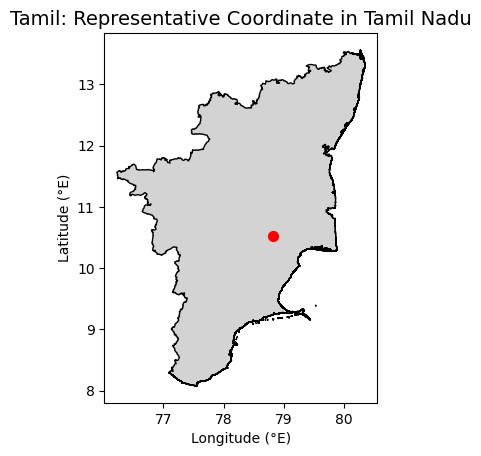

In [16]:
# plotting the polygon 
ax = tamil_nadu.plot(color="lightgrey", edgecolor="black")
# plotting the tamil gdf 
tamil_gdf.plot(ax=ax, color="red", markersize=50)
ax.set_title("Tamil: Representative Coordinate in Tamil Nadu", fontsize=14)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°E)")

In [22]:
### let's try to turn Malayalam into a geographical object now too  
malayalam_longitude_val = malayalam["longitude"].iloc[0]
malayalam_latitude_val = malayalam["latitude"].iloc[0]
# created a geometric object in coordinate space 
malayalam_point = Point(malayalam_longitude_val, malayalam_latitude_val)

In [23]:
type(malayalam_point)

shapely.geometry.point.Point

In [24]:
## need to put the point into a geodataframe 
malayalam_gdf = gpd.GeoDataFrame(
    {
        "name": ["Malayalam"],
        "iso": ["mal"],
        "geometry": [malayalam_point]
    },
    crs="EPSG:4326"
)

In [25]:
malayalam_gdf

,name,iso,geometry
0,Malayalam,mal,POINT (76.7651 9.59208)


In [26]:
kerala_state = india_states[india_states["NAME_1"] == "Kerala"]
kerala_state

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
19,IND.17_1,IND,India,Kerala,NA,NA,State,State,NA,IN.KL,IN-KL,"MULTIPOLYGON (((77.25153 8.57099, 77.2597 8.54..."


Text(192.38643661283254, 0.5, 'Latitude (°E)')

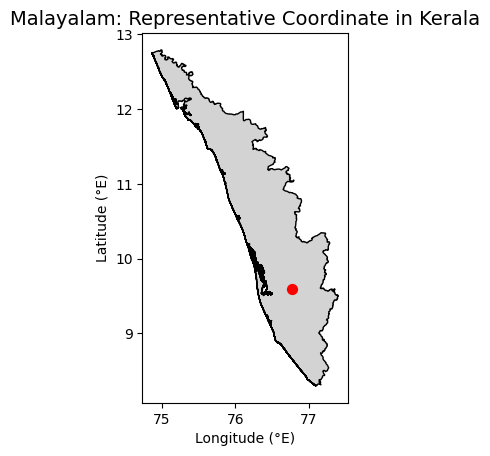

In [33]:
# plotting the polygon 
ax = kerala_state.plot(color="lightgrey", edgecolor="black")
# plotting the tamil gdf 
malayalam_gdf.plot(ax=ax, color="red", markersize=50)
ax.set_title("Malayalam: Representative Coordinate in Kerala", fontsize=14)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°E)")

In [45]:
df_lang = pd.read_csv("census_data.csv")
df_lang.head()

,state,language,speakers
0,Tamil Nadu,Tamil,69026881
1,Kerala,Malayalam,34838819
2,Andhra Pradesh,Telugu,81127740
3,Karnataka,Kannada,43706512


In [59]:
merged = india_states.merge(df_lang, left_on="NAME_1", right_on="state")
merged.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,state,language,speakers
0,IND.16_1,IND,India,Karnataka,Maisur|Mysore,NA,State,State,NA,IN.KA,IN-KA,"MULTIPOLYGON (((76.081 11.96067, 76.07281 11.9...",Karnataka,Kannada,43706512
1,IND.17_1,IND,India,Kerala,NA,NA,State,State,NA,IN.KL,IN-KL,"MULTIPOLYGON (((77.25153 8.57099, 77.2597 8.54...",Kerala,Malayalam,34838819
2,IND.31_1,IND,India,Tamil Nadu,Madras|Tamilnad,NA,State,State,NA,IN.TN,IN-TN,"MULTIPOLYGON (((77.55597 8.07708, 77.55597 8.0...",Tamil Nadu,Tamil,69026881


In [47]:
india_states["NAME_1"].unique()

<StringArray>
[   'Andaman and Nicobar',         'Andhra Pradesh',      'Arunachal Pradesh',
                  'Assam',                  'Bihar',             'Chandigarh',
           'Chhattisgarh', 'Dadra and Nagar Haveli',          'Daman and Diu',
                    'Goa',                'Gujarat',                'Haryana',
       'Himachal Pradesh',      'Jammu and Kashmir',              'Jharkhand',
              'Karnataka',                 'Kerala',            'Lakshadweep',
         'Madhya Pradesh',            'Maharashtra',                'Manipur',
              'Meghalaya',                'Mizoram',               'Nagaland',
           'NCT of Delhi',                 'Odisha',             'Puducherry',
                 'Punjab',              'Rajasthan',                 'Sikkim',
             'Tamil Nadu',              'Telangana',                'Tripura',
          'Uttar Pradesh',            'Uttarakhand',            'West Bengal']
Length: 36, dtype: str

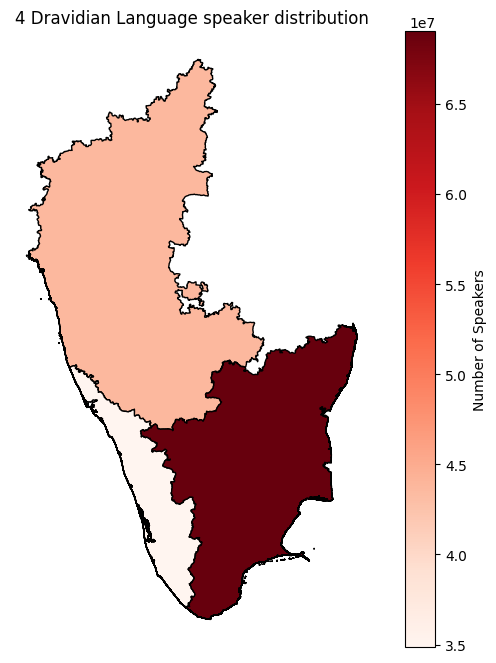

In [58]:
fig, ax = plt.subplots(figsize=(8,8))

merged.plot(
    column="speakers",
    cmap="Reds",
    legend=True,
    ax=ax, 
    edgecolor="black",
    legend_kwds={"label": "Number of Speakers"}
)

ax.set_title("4 Dravidian Language speaker distribution", fontsize=12)
ax.set_axis_off()

plt.show()